In [10]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# ============================================================
# DATASET PATH (Only edit this line if your Kaggle input name changes)
# ============================================================

DATASET_ROOT = Path("/kaggle/input/datasets/awsaf49/BDD100K-Dataset")

# ============================================================
# BDD100K DATASET
# ============================================================


TRAIN_IMAGES = Path("/kaggle/input/datasets/awsaf49/bdd100k-dataset/bdd100k/bdd100k/images/100k/train")
VAL_IMAGES = Path("/kaggle/input/datasets/awsaf49/bdd100k-dataset/bdd100k/bdd100k/images/100k/val")
TEST_IMAGES = Path("/kaggle/input/datasets/awsaf49/bdd100k-dataset/bdd100k/bdd100k/images/100k/test")


# Detection JSON annotations
TRAIN_JSON = Path("/kaggle/input/datasets/awsaf49/bdd100k-dataset/labels/det_v2_train_release.json")
VAL_JSON = Path("/kaggle/input/datasets/awsaf49/bdd100k-dataset/labels/det_v2_val_release.json")

# ============================================================
# PROJECT OUTPUT
# ============================================================

PROJECT_ROOT = Path("/kaggle/working/TrafficIQ")

RAW_DATA_DIR = PROJECT_ROOT / "raw_dataset"
YOLO_DATASET_DIR = PROJECT_ROOT / "yolo_dataset"

YOLO_IMAGES_DIR = YOLO_DATASET_DIR / "images"
YOLO_LABELS_DIR = YOLO_DATASET_DIR / "labels"

REPORT_DIR = PROJECT_ROOT / "reports"
CONFIG_DIR = PROJECT_ROOT / "configs"
MODEL_DIR = PROJECT_ROOT / "models"
METRICS_DIR = PROJECT_ROOT / "metrics"

for directory in [
    PROJECT_ROOT,
    RAW_DATA_DIR,
    YOLO_DATASET_DIR,
    YOLO_IMAGES_DIR,
    YOLO_LABELS_DIR,
    REPORT_DIR,
    CONFIG_DIR,
    MODEL_DIR,
    METRICS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("TrafficIQ - Notebook 01")
print("=" * 70)
print(f"Dataset Root : {DATASET_ROOT}")
print(f"BDD Root     : {BDD_ROOT}")
print(f"Project Root : {PROJECT_ROOT}")
print(f"Random Seed  : {SEED}")
print("=" * 70)

TrafficIQ - Notebook 01
Dataset Root : /kaggle/input/datasets/awsaf49/BDD100K-Dataset
BDD Root     : /kaggle/input/datasets/awsaf49/BDD100K-Dataset/bdd100k/bdd100k
Project Root : /kaggle/working/TrafficIQ
Random Seed  : 42


In [11]:
import json

print("=" * 70)
print("VERIFYING DATASET")
print("=" * 70)

required_paths = {
    "Train Images": TRAIN_IMAGES,
    "Validation Images": VAL_IMAGES,
    "Test Images": TEST_IMAGES,
    "Train JSON": TRAIN_JSON,
    "Validation JSON": VAL_JSON,
}

all_ok = True

for name, path in required_paths.items():
    exists = path.exists()
    status = "FOUND" if exists else "MISSING"
    print(f"{name:<20}: {status}")
    if not exists:
        all_ok = False

if not all_ok:
    raise FileNotFoundError(
        "\nDataset structure is incorrect. Check DATASET_ROOT."
    )

train_images = sorted(TRAIN_IMAGES.glob("*.jpg"))
val_images = sorted(VAL_IMAGES.glob("*.jpg"))
test_images = sorted(TEST_IMAGES.glob("*.jpg"))

print("\nImage Statistics")
print("-" * 70)
print(f"Train Images      : {len(train_images):,}")
print(f"Validation Images : {len(val_images):,}")
print(f"Test Images       : {len(test_images):,}")

with open(TRAIN_JSON, "r") as f:
    train_annotations = json.load(f)

with open(VAL_JSON, "r") as f:
    val_annotations = json.load(f)

print("\nAnnotation Statistics")
print("-" * 70)
print(f"Train Annotation Entries      : {len(train_annotations):,}")
print(f"Validation Annotation Entries : {len(val_annotations):,}")

sample = train_annotations[0]

print("\nSample Image")
print("-" * 70)
print(f"Image Name : {sample['name']}")
print(f"Objects    : {len(sample.get('labels', []))}")

print("\nSample Object Categories")
print("-" * 70)

categories = set()

for item in train_annotations[:500]:
    for obj in item.get("labels", []):
        if "category" in obj:
            categories.add(obj["category"])

print(sorted(categories))

print("\nDataset verification completed successfully.")
print("=" * 70)

VERIFYING DATASET
Train Images        : FOUND
Validation Images   : FOUND
Test Images         : FOUND
Train JSON          : FOUND
Validation JSON     : FOUND

Image Statistics
----------------------------------------------------------------------
Train Images      : 70,000
Validation Images : 10,000
Test Images       : 20,000

Annotation Statistics
----------------------------------------------------------------------
Train Annotation Entries      : 69,863
Validation Annotation Entries : 10,000

Sample Image
----------------------------------------------------------------------
Image Name : 0000f77c-6257be58.jpg
Objects    : 7

Sample Object Categories
----------------------------------------------------------------------
['bicycle', 'bus', 'car', 'motorcycle', 'pedestrian', 'rider', 'traffic light', 'traffic sign', 'train', 'truck']

Dataset verification completed successfully.


In [12]:
TRAFFIQ_CLASSES = [
    "pedestrian",
    "rider",
    "bicycle",
    "motorcycle",
    "car",
    "bus",
    "truck",
    "traffic light",
    "traffic sign",
    "train",
]

CLASS_TO_ID = {
    name: idx
    for idx, name in enumerate(TRAFFIQ_CLASSES)
}

ID_TO_CLASS = {
    idx: name
    for name, idx in CLASS_TO_ID.items()
}

print("=" * 70)
print("TrafficIQ Detection Classes")
print("=" * 70)

for idx, cls in ID_TO_CLASS.items():
    print(f"{idx:2d} -> {cls}")

import yaml

dataset_yaml = {
    "path": str(YOLO_DATASET_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": ID_TO_CLASS
}

with open(CONFIG_DIR / "dataset.yaml", "w") as f:
    yaml.safe_dump(dataset_yaml, f, sort_keys=False)

print("\nDataset configuration saved to:")
print(CONFIG_DIR / "dataset.yaml")

TrafficIQ Detection Classes
 0 -> pedestrian
 1 -> rider
 2 -> bicycle
 3 -> motorcycle
 4 -> car
 5 -> bus
 6 -> truck
 7 -> traffic light
 8 -> traffic sign
 9 -> train

Dataset configuration saved to:
/kaggle/working/TrafficIQ/configs/dataset.yaml


In [16]:
import json
import shutil

IMAGE_WIDTH = 1280
IMAGE_HEIGHT = 720

YOLO_IMAGES_TRAIN = YOLO_IMAGES_DIR / "train"
YOLO_IMAGES_VAL = YOLO_IMAGES_DIR / "val"

YOLO_LABELS_TRAIN = YOLO_LABELS_DIR / "train"
YOLO_LABELS_VAL = YOLO_LABELS_DIR / "val"

for folder in [
    YOLO_IMAGES_TRAIN,
    YOLO_IMAGES_VAL,
    YOLO_LABELS_TRAIN,
    YOLO_LABELS_VAL,
]:
    folder.mkdir(parents=True, exist_ok=True)


def convert_annotations(annotation_file, image_root, output_image_dir, output_label_dir):

    with open(annotation_file, "r") as f:
        annotations = json.load(f)

    image_counter = 0
    object_counter = 0

    for sample in tqdm(annotations):

        image_name = sample["name"]
        image_path = image_root / image_name

        if not image_path.exists():
            continue

        yolo_lines = []

        for obj in (sample.get("labels") or []):

            category = obj.get("category")

            if category not in CLASS_TO_ID:
                continue

            if obj.get("box2d") is None:
                continue

            box = obj["box2d"]

            x1 = max(0, min(IMAGE_WIDTH, box["x1"]))
            y1 = max(0, min(IMAGE_HEIGHT, box["y1"]))
            x2 = max(0, min(IMAGE_WIDTH, box["x2"]))
            y2 = max(0, min(IMAGE_HEIGHT, box["y2"]))

            if x2 <= x1 or y2 <= y1:
                continue

            xc = ((x1 + x2) / 2) / IMAGE_WIDTH
            yc = ((y1 + y2) / 2) / IMAGE_HEIGHT
            w = (x2 - x1) / IMAGE_WIDTH
            h = (y2 - y1) / IMAGE_HEIGHT

            yolo_lines.append(
                f"{CLASS_TO_ID[category]} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}"
            )

            object_counter += 1

        if len(yolo_lines) == 0:
            continue

        if not (output_image_dir / image_name).exists():
            shutil.copy2(image_path, output_image_dir / image_name)

        with open(output_label_dir / image_name.replace(".jpg", ".txt"), "w") as f:
            f.write("\n".join(yolo_lines))

        image_counter += 1

    return image_counter, object_counter


print("=" * 70)
print("Converting Training Dataset")
print("=" * 70)

train_images, train_objects = convert_annotations(
    TRAIN_JSON,
    TRAIN_IMAGES,
    YOLO_IMAGES_TRAIN,
    YOLO_LABELS_TRAIN,
)

print("=" * 70)
print("Converting Validation Dataset")
print("=" * 70)

val_images, val_objects = convert_annotations(
    VAL_JSON,
    VAL_IMAGES,
    YOLO_IMAGES_VAL,
    YOLO_LABELS_VAL,
)

print("\nConversion Complete")
print("-" * 70)

print(f"Training Images    : {train_images:,}")
print(f"Training Objects   : {train_objects:,}")
print(f"Validation Images  : {val_images:,}")
print(f"Validation Objects : {val_objects:,}")

print("\nYOLO Dataset")
print(YOLO_DATASET_DIR)

Converting Training Dataset


  0%|          | 0/69863 [00:00<?, ?it/s]

Converting Validation Dataset


  0%|          | 0/10000 [00:00<?, ?it/s]


Conversion Complete
----------------------------------------------------------------------
Training Images    : 69,853
Training Objects   : 1,273,707
Validation Images  : 10,000
Validation Objects : 185,945

YOLO Dataset
/kaggle/working/TrafficIQ/yolo_dataset


# Validate Converted YOLO Dataset

This notebook performs quality assurance on the converted YOLO dataset before model training.

The validation process includes:

- Dataset integrity verification
- Image-label consistency checks
- Bounding box validation
- Class distribution analysis
- Bounding box statistics
- Random visualization of annotations
- Dataset quality report generation

Running these checks before training helps prevent wasted GPU time caused by corrupted labels, invalid bounding boxes, or preprocessing errors.

In [17]:
import os
import random
from pathlib import Path

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path("/kaggle/working/TrafficIQ")

YOLO_ROOT = PROJECT_ROOT / "yolo_dataset"

TRAIN_IMAGES = YOLO_ROOT / "images" / "train"
VAL_IMAGES = YOLO_ROOT / "images" / "val"

TRAIN_LABELS = YOLO_ROOT / "labels" / "train"
VAL_LABELS = YOLO_ROOT / "labels" / "val"

REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(exist_ok=True)

CONFIG_PATH = PROJECT_ROOT / "configs" / "dataset.yaml"

print("TrafficIQ Dataset Validation")

TrafficIQ Dataset Validation


In [18]:
with open(CONFIG_PATH) as f:
    dataset_config = yaml.safe_load(f)

CLASS_NAMES = dataset_config["names"]

NUM_CLASSES = len(CLASS_NAMES)

print("Classes\n")

for i in range(NUM_CLASSES):
    print(f"{i:2d} : {CLASS_NAMES[i]}")

Classes

 0 : pedestrian
 1 : rider
 2 : bicycle
 3 : motorcycle
 4 : car
 5 : bus
 6 : truck
 7 : traffic light
 8 : traffic sign
 9 : train


In [19]:
train_images = sorted(TRAIN_IMAGES.glob("*.jpg"))
train_labels = sorted(TRAIN_LABELS.glob("*.txt"))

val_images = sorted(VAL_IMAGES.glob("*.jpg"))
val_labels = sorted(VAL_LABELS.glob("*.txt"))

print("=" * 60)

print(f"Train Images : {len(train_images):,}")
print(f"Train Labels : {len(train_labels):,}")

print(f"Val Images   : {len(val_images):,}")
print(f"Val Labels   : {len(val_labels):,}")

assert len(train_images) == len(train_labels)
assert len(val_images) == len(val_labels)

print("\nDataset integrity passed.")

Train Images : 69,853
Train Labels : 69,853
Val Images   : 10,000
Val Labels   : 10,000

Dataset integrity passed.


In [20]:
class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)

invalid_boxes = 0
total_boxes = 0

widths = []
heights = []

for label_file in tqdm(train_labels):

    with open(label_file) as f:

        lines = f.readlines()

    for line in lines:

        cls, xc, yc, w, h = map(float, line.split())

        cls = int(cls)

        total_boxes += 1

        class_counts[cls] += 1

        widths.append(w)
        heights.append(h)

        if (
            xc < 0
            or yc < 0
            or xc > 1
            or yc > 1
            or w <= 0
            or h <= 0
            or w > 1
            or h > 1
        ):
            invalid_boxes += 1

print(f"Total Objects : {total_boxes:,}")
print(f"Invalid Boxes : {invalid_boxes}")

  0%|          | 0/69853 [00:00<?, ?it/s]

Total Objects : 1,273,707
Invalid Boxes : 0


In [21]:
distribution = pd.DataFrame({
    "Class": [CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    "Objects": class_counts
})

distribution = distribution.sort_values(
    "Objects",
    ascending=False
)

distribution

,Class,Objects
4,car,700703
8,traffic sign,238270
7,traffic light,187871
0,pedestrian,92159
6,truck,27892
5,bus,11977
2,bicycle,7124
1,rider,4560
3,motorcycle,3023
9,train,128


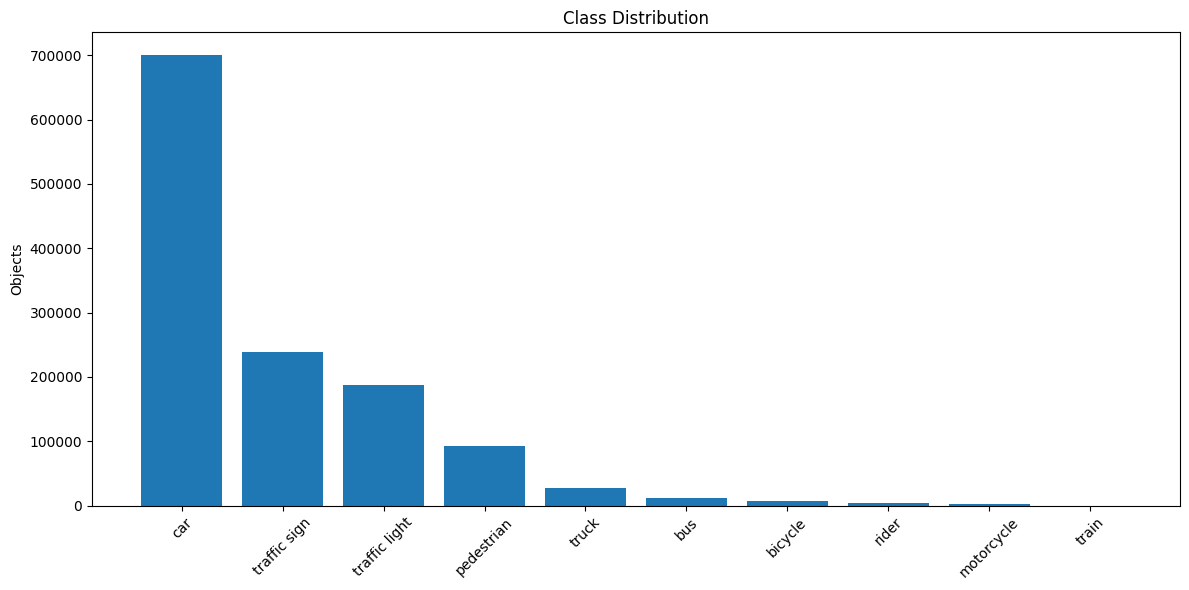

In [22]:
plt.figure(figsize=(12,6))

plt.bar(
    distribution["Class"],
    distribution["Objects"]
)

plt.xticks(rotation=45)

plt.ylabel("Objects")

plt.title("Class Distribution")

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "class_distribution.png",
    dpi=300
)

plt.show()

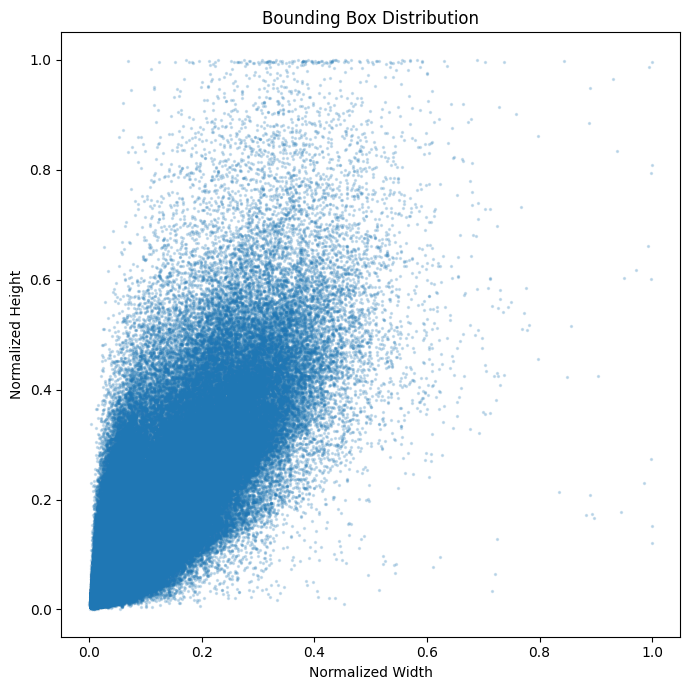

In [23]:
plt.figure(figsize=(7,7))

plt.scatter(
    widths,
    heights,
    s=2,
    alpha=0.2
)

plt.xlabel("Normalized Width")

plt.ylabel("Normalized Height")

plt.title("Bounding Box Distribution")

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "bbox_distribution.png",
    dpi=300
)

plt.show()

In [24]:
COLORS = np.random.randint(
    0,
    255,
    (NUM_CLASSES,3)
)

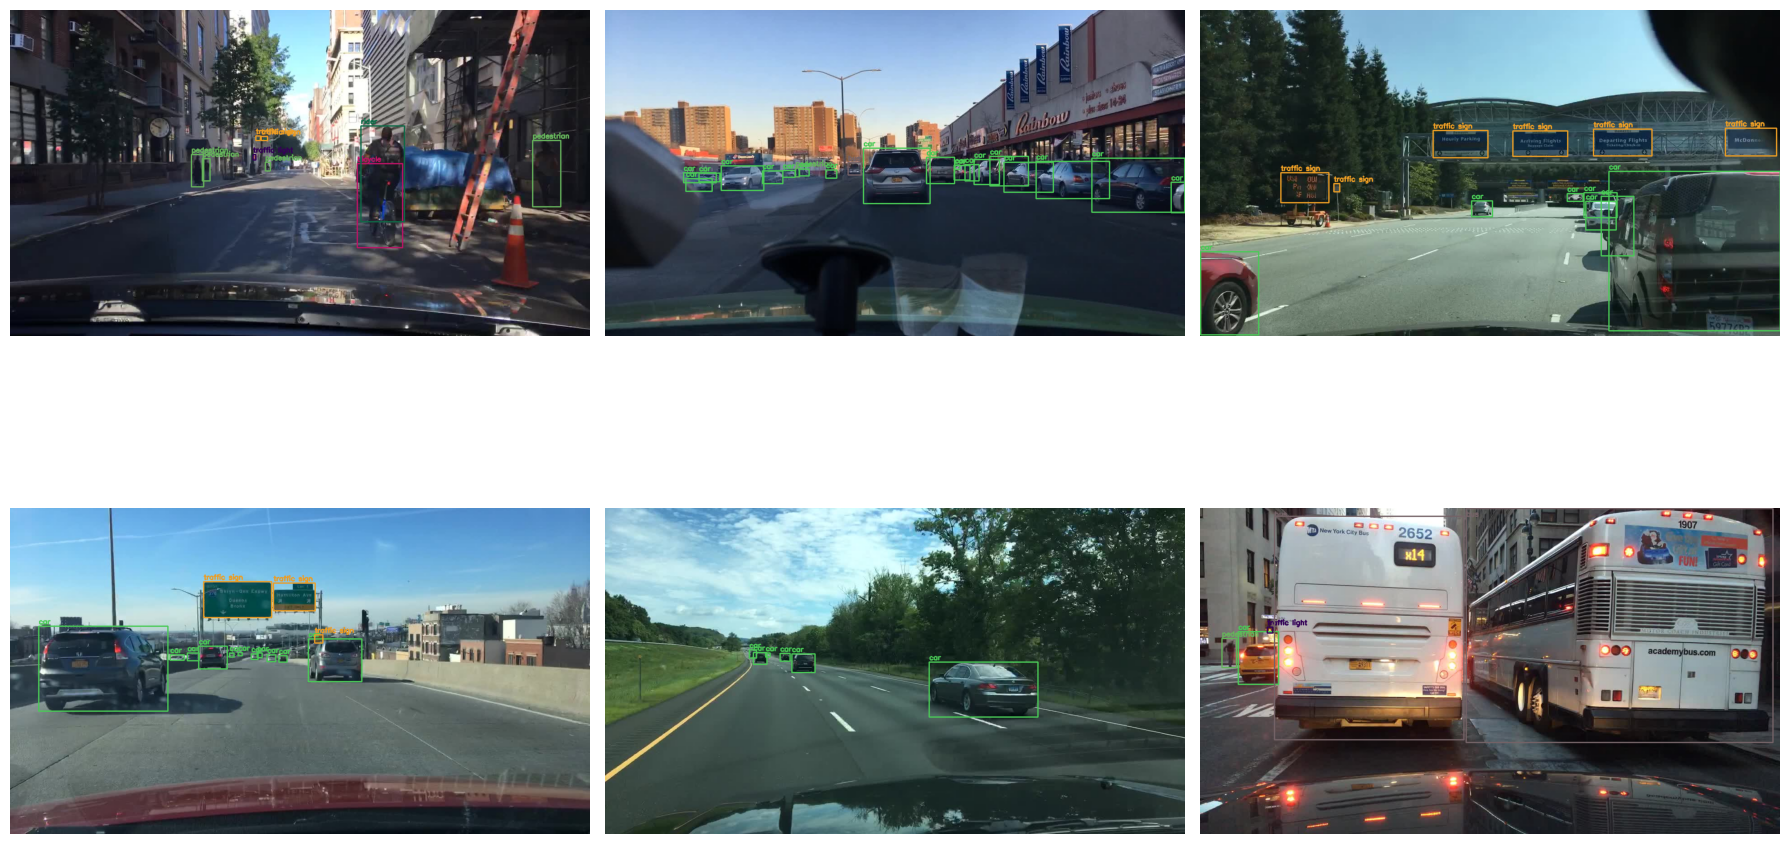

In [25]:
samples = random.sample(train_images, 6)

plt.figure(figsize=(18,12))

for i, image_path in enumerate(samples):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    label_file = TRAIN_LABELS / image_path.with_suffix(".txt").name

    with open(label_file) as f:

        for line in f:

            cls, xc, yc, bw, bh = map(float, line.split())

            cls = int(cls)

            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)

            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)

            color = COLORS[cls].tolist()

            cv2.rectangle(
                image,
                (x1,y1),
                (x2,y2),
                color,
                2
            )

            cv2.putText(
                image,
                CLASS_NAMES[cls],
                (x1,max(20,y1-5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                color,
                2
            )

    plt.subplot(2,3,i+1)

    plt.imshow(image)

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "sample_annotations.png",
    dpi=300
)

plt.show()

In [26]:
summary = pd.DataFrame({

    "Metric":[
        "Training Images",
        "Validation Images",
        "Training Labels",
        "Validation Labels",
        "Classes",
        "Objects",
        "Invalid Boxes"
    ],

    "Value":[
        len(train_images),
        len(val_images),
        len(train_labels),
        len(val_labels),
        NUM_CLASSES,
        total_boxes,
        invalid_boxes
    ]
})

summary.to_csv(
    REPORT_DIR / "dataset_summary.csv",
    index=False
)

summary

,Metric,Value
0,Training Images,69853
1,Validation Images,10000
2,Training Labels,69853
3,Validation Labels,10000
4,Classes,10
5,Objects,1273707
6,Invalid Boxes,0
